# Unit 5 Exercise: Training Skip-gram with Negative Sampling
**Name:** Axel John Nuqui | Joelmar Grecia

**Date:** April 10, 2026  
**Topic:** Artificial Intelligence Wikipedia Corpus

In [8]:
import re
import math
import json
import random
from collections import Counter
from typing import List, Tuple, Dict

import requests
from bs4 import BeautifulSoup
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# constants
WIKI_URL = "https://en.wikipedia.org/wiki/Artificial_intelligence"
RANDOM_SEED = 42

def ensure_nltk():
    resources = ["punkt", "punkt_tab"]
    for r in resources:
        try:
            nltk.data.find(f"tokenizers/{r}")
        except LookupError:
            nltk.download(r)
            
ensure_nltk()

In [9]:
# fetching and preprocessing data
def fetch_wikipedia_article(url: str) -> str:
    headers = {"User-Agent": "Mozilla/5.0 (compatible; SGNS-AI-Training/1.0)"}
    resp = requests.get(url, headers=headers, timeout=30)
    resp.raise_for_status()
    soup = BeautifulSoup(resp.text, "html.parser")
    content_div = soup.find("div", {"id": "mw-content-text"})
    paragraphs = content_div.find_all(["p", "li"])
    text_blocks = [p.get_text(" ", strip=True) for p in paragraphs if p.get_text(" ", strip=True)]
    text = "\n".join(text_blocks)
    text = re.sub(r"\[[0-9]+\]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

def preprocess_text(text: str) -> List[List[str]]:
    sentences = sent_tokenize(text)
    processed = []
    for sent in sentences:
        sent = sent.lower()
        sent = re.sub(r"[^a-z0-9\-\s]", " ", sent)
        tokens = word_tokenize(sent)
        cleaned = [tok.strip("-") for tok in tokens if not tok.isdigit() and len(tok) >= 2]
        if len(cleaned) >= 3:
            processed.append(cleaned)
    return processed

raw_text = fetch_wikipedia_article(WIKI_URL)
sentences = preprocess_text(raw_text)
print(f"Corpus Preprocessed: {len(sentences)} sentences found.")

Corpus Preprocessed: 1735 sentences found.


In [10]:
# function to train with custom window size
def train_sgns_custom(sentences: List[List[str]], window_size: int) -> Word2Vec:
    model = Word2Vec(
        sentences=sentences,
        vector_size=100,
        window=window_size,
        min_count=1,
        workers=4,
        sg=1,           # Skip-gram 
        negative=10,    # Negative sampling 
        epochs=200,
        seed=RANDOM_SEED,
    )
    return model

# training the "OLD" model (Window = 5) 
print("Training Model (Window=5)...")
model_v5 = train_sgns_custom(sentences, window_size=5)

# training the "NEW" model (Window = 10) 
print("Training Model (Window=10)...")
model_v10 = train_sgns_custom(sentences, window_size=10)

print(f"\nTraining Complete.")
print(f"Vocabulary size learned: {len(model_v5.wv)}") # Both will have the same vocab size

Training Model (Window=5)...


Training Model (Window=10)...

Training Complete.
Vocabulary size learned: 5406


In [ ]:
# evaluation and testing
def has_word(model, word): 
    return word in model.wv.key_to_index

def cosine(model, w1, w2):
    v1 = model.wv[w1].reshape(1, -1)
    v2 = model.wv[w2].reshape(1, -1)
    return float(cosine_similarity(v1, v2)[0][0])

probe_words = [
    "ai", "intelligence", "machine", "learning", "neural", 
    "network", "data", "algorithm", "robot", "turing"
]

# dictionary to store our models for easy looping
models = {
    "Window Size: 5 (OLD)": model_v5,
    "Window Size: 10 (NEW)": model_v10
}

for label, model_obj in models.items():
    print(f"\n{'='*30}")
    print(f"  RESULTS FOR {label}")
    print(f"{'='*30}")
    
    print("\n=== Top 5 Nearest Neighbors ===")
    for word in probe_words:
        if has_word(model_obj, word):
            neighbors = model_obj.wv.most_similar(word, topn=5)
            print(f"\n{word.upper()}:")
            for n, s in neighbors: 
                print(f"   {n:20s} {s:.4f}")
        else:
            print(f"\n{word.upper()}: [OOV]")


  RESULTS FOR Window Size: 5 (OLD)

=== Top 5 Nearest Neighbors ===

AI:
   uncontroversial      0.4414
   literacy             0.4324
   veganism             0.4310
   slop                 0.4178
   bubble               0.4150

INTELLIGENCE:
   artificial           0.8605
   instrumental         0.5414
   journals             0.5374
   3rd                  0.5160
   4th                  0.5158

MACHINE:
   in-context           0.5118
   perspectives         0.5083
   directing            0.5077
   learning             0.5066
   prospects            0.5001

LEARNING:
   prospects            0.5715
   aa                   0.5706
   perspectives         0.5677
   coding               0.5531
   in-context           0.5472

NEURAL:
   networks             0.7176
   convolutional        0.6626
   continuous           0.6109
   handwritten          0.5975
   lstms                0.5915

NETWORK:
   components           0.7423
   scheduler            0.7396
   highway              0.7083
   

In [ ]:
# relatedness and analogy comparison for both models

relatedness_test = [
    ("artificial", "intelligence", 0.95),
    ("machine", "learning", 0.95),
    ("deep", "learning", 0.90),
    ("neural", "network", 0.95),
    ("data", "information", 0.80),
    ("algorithm", "model", 0.85),
    ("ai", "robot", 0.70),
    ("intelligence", "human", 0.60),
    ("ai", "banana", 0.05),
    ("learning", "car", 0.10),
]

analogy_test = [
    ("human", "intelligence", "machine", "artificial"),
    ("learning", "data", "vision", "image"),
    ("science", "biology", "ai", "robotics"),
    ("pilot", "cockpit", "driver", "car"), 
]

# dictionary to store models for comparison
models_to_test = {
    "WINDOW 5 (OLD)": model_v5,
    "WINDOW 10 (NEW)": model_v10
}

for label, model_obj in models_to_test.items():
    print(f"\n{'='*40}")
    print(f"  EVALUATION FOR {label}")
    print(f"{'='*40}")

    # Relatedness Output
    print("\n--- Relatedness Test Set ---")
    for w1, w2, gold in relatedness_test:
        if has_word(model_obj, w1) and has_word(model_obj, w2):
            # Using model_obj.wv.similarity for direct cosine comparison
            pred = model_obj.wv.similarity(w1, w2)
            print(f"{w1:12} - {w2:12} | gold={gold:.2f} pred={pred:.4f}")
        else:
            print(f"{w1:12} - {w2:12} | [OOV]")

    # Analogy Output
    print("\n--- Analogy Test Set ---")
    for a, b, c, d in analogy_test:
        if all(has_word(model_obj, w) for w in [a, b, c, d]):
            preds = model_obj.wv.most_similar(positive=[b, c], negative=[a], topn=5)
            hit = d in [w for w, _ in preds]
            top_pred = preds[0][0]
            print(f"{a}:{b} :: {c}:? | Exp: {d:10} | Top Match: {top_pred:10} | Correct in Top-5: {hit}")
        else:
            print(f"{a}:{b} :: {c}:? | [OOV]")


  EVALUATION FOR WINDOW 5 (OLD)

--- Relatedness Test Set ---
artificial   - intelligence | gold=0.95 pred=0.8605
machine      - learning     | gold=0.95 pred=0.5066
deep         - learning     | gold=0.90 pred=0.5146
neural       - network      | gold=0.95 pred=0.5773
data         - information  | gold=0.80 pred=0.2978
algorithm    - model        | gold=0.85 pred=0.2800
ai           - robot        | gold=0.70 pred=0.1030
intelligence - human        | gold=0.60 pred=0.2736
ai           - banana       | [OOV]
learning     - car          | gold=0.10 pred=0.1735

--- Analogy Test Set ---
human:intelligence :: machine:? | Exp: artificial | Top Match: artificial | Correct in Top-5: True
learning:data :: vision:? | Exp: image      | Top Match: raised     | Correct in Top-5: False
science:biology :: ai:? | Exp: robotics   | Top Match: transforming | Correct in Top-5: False
pilot:cockpit :: driver:? | [OOV]

  EVALUATION FOR WINDOW 10 (NEW)

--- Relatedness Test Set ---
artificial   - intelli

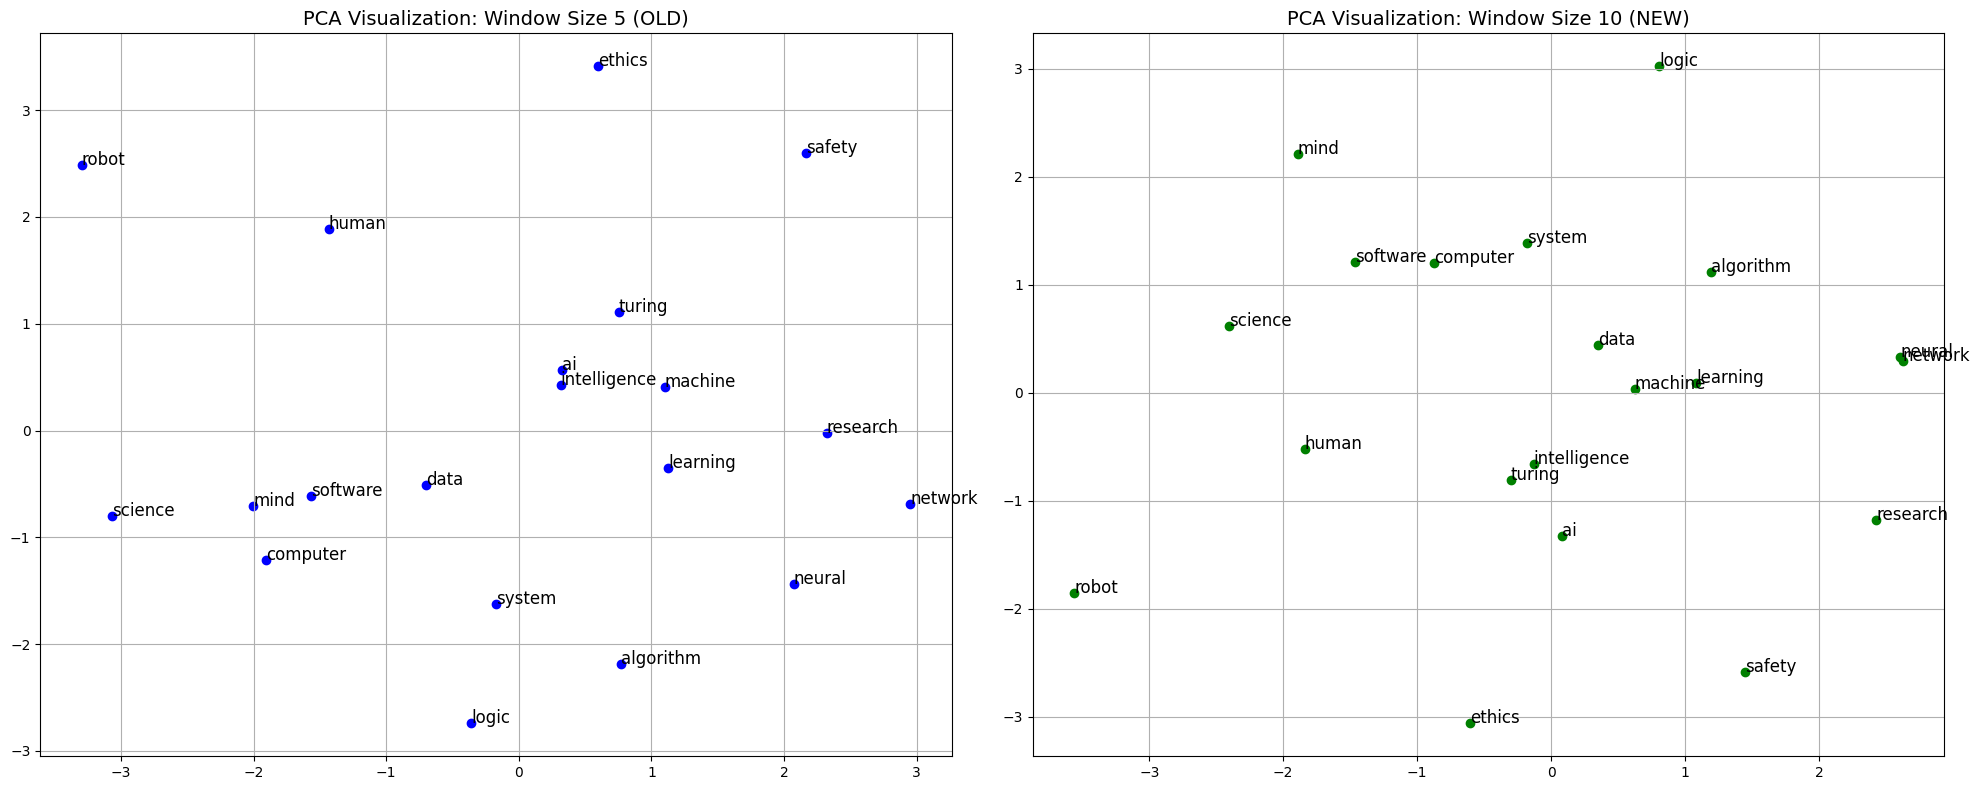

In [13]:
# PCA Visualization for Model Comparison
def visualize_pca_comparison(model_old, model_new, words):
    # Filter valid words for both models
    valid_words = [w for w in words if w in model_old.wv and w in model_new.wv]
    
    # Set up the plot area
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    pca = PCA(n_components=2)

    # Plot for Window 5 (OLD)
    vectors_5 = [model_old.wv[w] for w in valid_words]
    result_5 = pca.fit_transform(vectors_5)
    ax1.scatter(result_5[:, 0], result_5[:, 1], color='blue')
    for i, word in enumerate(valid_words):
        ax1.annotate(word, (result_5[i, 0], result_5[i, 1]), fontsize=12)
    ax1.set_title("PCA Visualization: Window Size 5 (OLD)", fontsize=14)
    ax1.grid(True)

    # Plot for Window 10 (NEW)
    vectors_10 = [model_new.wv[w] for w in valid_words]
    result_10 = pca.fit_transform(vectors_10)
    ax2.scatter(result_10[:, 0], result_10[:, 1], color='green')
    for i, word in enumerate(valid_words):
        ax2.annotate(word, (result_10[i, 0], result_10[i, 1]), fontsize=12)
    ax2.set_title("PCA Visualization: Window Size 10 (NEW)", fontsize=14)
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

# List of at least 20 words for visualization as required by the exercise
viz_words = [
    "intelligence", "human", "machine", "learning", "neural", "network", 
    "turing", "robot", "data", "algorithm", "logic", "science", "mind", 
    "system", "ethics", "safety", "ai", "research", "computer", "software"
]

visualize_pca_comparison(model_v5, model_v10, viz_words)

In [14]:
# save both models
model_v5.save("exercise_5_v5_window.model")
model_v10.save("exercise_5_v10_window.model")

print("\nModels saved successfully:")
print("- Window 5: exercise_5_v5_window.model")
print("- Window 10: exercise_5_v10_window.model")


Models saved successfully:
- Window 5: exercise_5_v5_window.model
- Window 10: exercise_5_v10_window.model
